In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import xgboost as xgb
import shap
import glob
import os
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

C:\Users\WINDOWS 11\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting OLS Model
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.3113      2.803      1.538      0.125      -1.210       9.833
C(person)[T.김장훈]        4.9362      3.245      1.521      0.130      -1.457      11.329
C(person)[T.남보라]       -0.3075      3.248     -0.095      0.925      -6.706       6.091
C(person)[T.박서준]       -2.6825      3.248     -0.826      0.410      -9.081       3.716
C(person)[T.사유리]        2.7550      3.248      0.848      0.397      -3.644       9.154
C(person)[T.송지은]       -1.3763      2.810     -0.490      0.625      -6.911       4.159
C(person)[T.유빈]         4.5612      3.245      1.406      0.161      -1.832      10.954
C(person)[T.이경규]        6.1926      3.248      1.907      0.058      -0.206      12.592
C(person)[T.이천수]        4.7793      2.811      1.700      0.090      -0.759      10.318
C(person)[T.임우

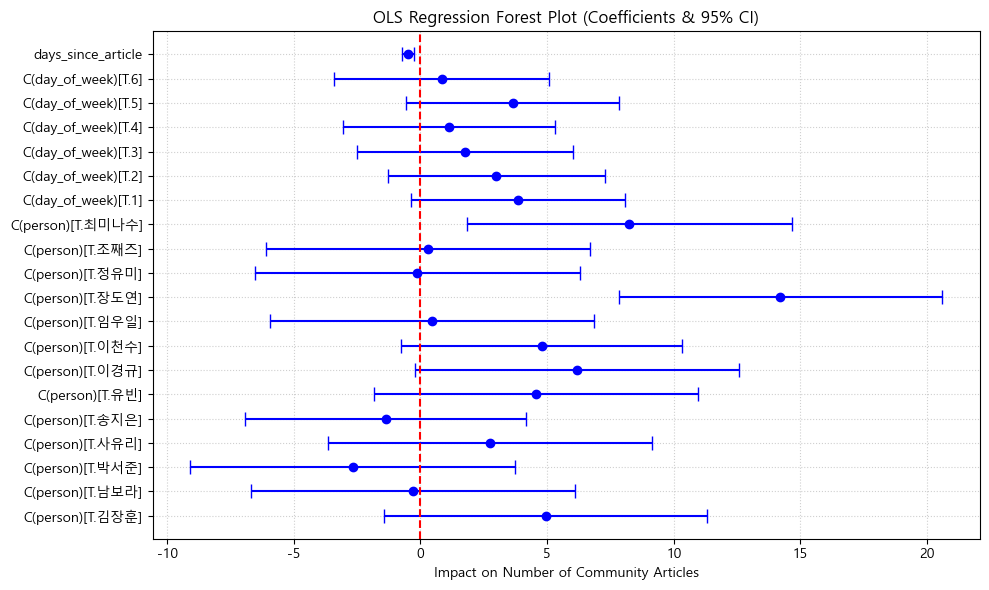

Fitting XGBoost Model


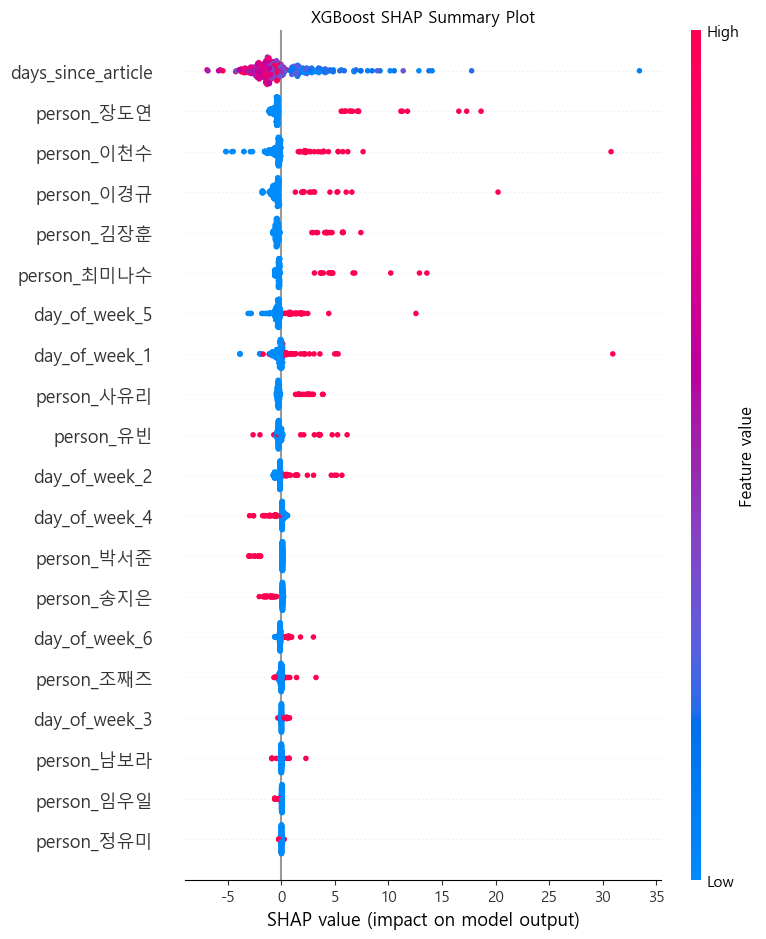


--- Model R-Squared Comparison ---
OLS R^2 (Full Data): 0.2470
XGB R^2 (Test Data): -0.0953


In [2]:
# Set up Korean font for Windows
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

article_csv_path = r"../data\name_article_time.csv"
list_files = glob.glob(r"../data\*_list.csv")

# Load Article Times
articles_df = pd.read_csv(article_csv_path)
articles_df['article_time'] = pd.to_datetime(articles_df['article_time'], format='%Y-%m-%d-%H-%M')

# Load all Community Data
comm_list = []
for f in list_files:
    temp_df = pd.read_csv(f, usecols=['keyword', 'time'])
    comm_list.append(temp_df)
all_comm_df = pd.concat(comm_list, ignore_index=True)
all_comm_df['time'] = pd.to_datetime(all_comm_df['time'], format='%Y.%m.%d %H:%M')

records = []

for idx, row in articles_df.iterrows():
    person = row['name']
    art_date = row['article_time'].normalize() 
    
    person_comm = all_comm_df[all_comm_df['keyword'] == person]
    daily_counts = person_comm.set_index('time').resample('D').size()
    
    # Track mentions for day 0 through 15
    for day_offset in range(16):
        target_date = art_date + timedelta(days=day_offset)
        y_count = daily_counts.get(target_date, 0)
        
        records.append({
            'event_id': f"{person}_Event_{idx+1}",
            'person': person,
            'days_since_article': day_offset,
            'day_of_week': target_date.weekday(), # 0=Mon, 6=Sun
            'mentions': y_count
        })

df_reg = pd.DataFrame(records)
df_reg['day_of_week'] = df_reg['day_of_week'].astype(str) 

# OLS & FOREST PLOT
print("Fitting OLS Model")
ols_model = smf.ols('mentions ~ days_since_article + C(person) + C(day_of_week)', data=df_reg).fit()
print(ols_model.summary().tables[1])

# Forest Plot
plt.figure(figsize=(10, 6))
coefs = ols_model.params.drop('Intercept')
conf_ints = ols_model.conf_int().drop('Intercept')
errors = coefs - conf_ints[0]

plt.errorbar(coefs, coefs.index, xerr=errors, fmt='o', color='b', capsize=5)
plt.axvline(0, color='red', linestyle='--') 
plt.title('OLS Regression Forest Plot (Coefficients & 95% CI)')
plt.xlabel('Impact on Number of Community Articles')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# GRADIENT BOOSTING (XGBoost) & SHAP
print("Fitting XGBoost Model")

X = pd.get_dummies(df_reg[['days_since_article', 'person', 'day_of_week']], drop_first=True).astype(float)
y = df_reg['mentions']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# SHAP Plot (Visualizing the impact on the entire dataset for full context)
explainer = shap.Explainer(xgb_model, X)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
plt.title("XGBoost SHAP Summary Plot")
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()

# 5. FINAL R-SQUARED COMPARISON
xgb_predictions = xgb_model.predict(X_test)

print("\n--- Model R-Squared Comparison ---")
print(f"OLS R^2 (Full Data): {ols_model.rsquared:.4f}")
print(f"XGB R^2 (Test Data): {r2_score(y_test, xgb_predictions):.4f}")